<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/01_machine_learning_foundations/30_pca_component_selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA Component Selection

In this notebook, we analyze how many principal components should be retained by studying explained variance and cumulative variance.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
X, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=6,
    random_state=42
)

print(X.shape)

(500, 10)


In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [4]:
pca = PCA()

pca.fit(X_scaled)

PCA()

In [5]:
print(
    pca.explained_variance_ratio_
)

[2.40718413e-01 2.07886591e-01 1.30097565e-01 1.04122552e-01
 9.98992130e-02 9.72565603e-02 8.02337508e-02 3.97853545e-02
 7.60810391e-17 1.25589873e-17]


In [6]:
cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)

[0.24071841 0.448605   0.57870257 0.68282512 0.78272433 0.87998089
 0.96021465 1.         1.         1.        ]


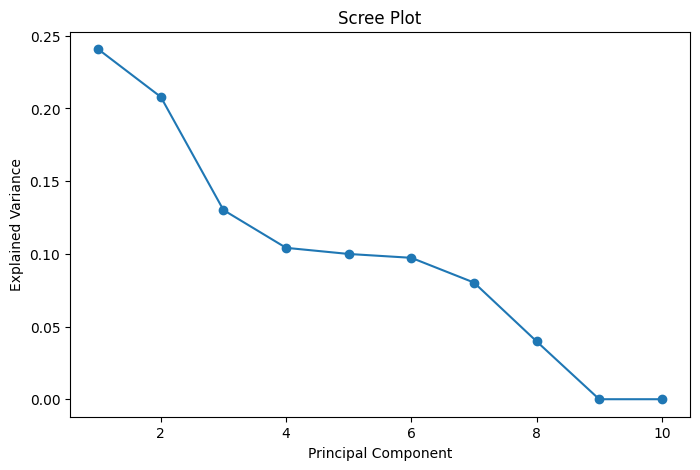

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    range(
        1,
        len(pca.explained_variance_ratio_) + 1
    ),
    pca.explained_variance_ratio_,
    marker='o'
)

plt.xlabel("Principal Component")

plt.ylabel("Explained Variance")

plt.title("Scree Plot")

plt.show()

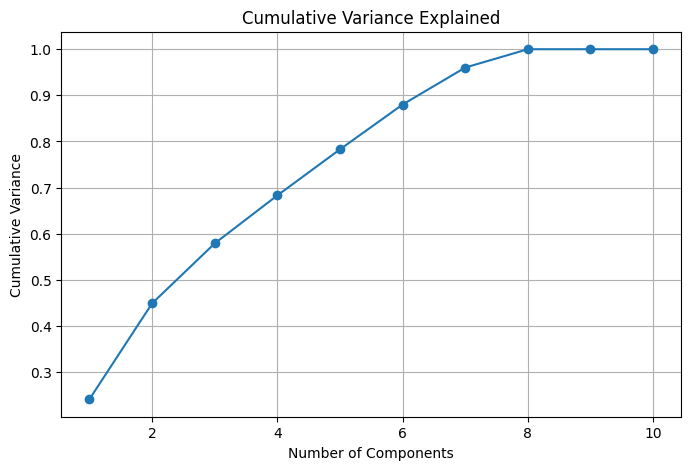

In [8]:
plt.figure(figsize=(8,5))

plt.plot(
    range(
        1,
        len(cumulative_variance) + 1
    ),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Components")

plt.ylabel("Cumulative Variance")

plt.title(
    "Cumulative Variance Explained"
)

plt.grid()

plt.show()

In [9]:
components_needed = np.argmax(
    cumulative_variance >= 0.90
) + 1

print(
    "Components needed for 90% variance:",
    components_needed
)

Components needed for 90% variance: 7


In [10]:
summary = pd.DataFrame({
    "Component":
    range(
        1,
        len(cumulative_variance)+1
    ),

    "Cumulative Variance":
    cumulative_variance
})

summary

,Component,Cumulative Variance
0,1,0.240718
1,2,0.448605
2,3,0.578703
3,4,0.682825
4,5,0.782724
5,6,0.879981
6,7,0.960215
7,8,1.000000
8,9,1.000000
9,10,1.000000


## Conclusion

This notebook analyzed how much information each principal component retains.

Observations:
- Earlier components retain most information.
- Later components contribute less variance.
- PCA helps identify the minimum number of components needed while preserving important information.
- Component selection is based on cumulative variance rather than guessing.